In [39]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

True

In [40]:
class blogState(TypedDict):
    topic: str
    outline: str
    blog_post: str
    evaluation_score: int

In [46]:
class Evaluation(BaseModel):
    content: int = Field(description="Score out of 10", ge=1, le=10)

In [47]:
outlineTemplate = PromptTemplate(
    template='Based on the following given topic - {topic}, please provide a detailed outline for a blog post. The outline should include the main sections and sub-sections, along with brief descriptions of what each section will cover. Please format the outline in a clear and organized manner.',
    input_variables=['topic']
)

In [48]:
contentTemplate = PromptTemplate(
    template='Based on the following outline - {outline}, please write a detailed blog post. The blog post should be well-structured, engaging, and informative. Please ensure that the content flows logically from one section to the next, and that it provides valuable insights and information to the reader.',
    input_variables=['outline']
)

In [49]:
evaluateTemplate = PromptTemplate(
    template='Evaluate the following blog post against the given outline.\n\nOutline:\n{outline}\n\nBlog post:\n{blog_post}\n\nScore how well the post adheres to the outline and covers the main points, on a scale of 1 to 10. Respond with the score only as a single integer.',
    input_variables=['blog_post', 'outline']
)

In [50]:
model = ChatOpenAI()
parser = StrOutputParser()

In [51]:
def generate_outline(state: blogState) -> blogState:
    topic = state['topic']
    chain = outlineTemplate | model | parser
    state['outline'] = chain.invoke(topic)
    return state

In [57]:
def generate_content(state: blogState) -> blogState:
    outline = state['outline']
    chain = contentTemplate | model | parser
    blog_post = chain.invoke(input={'outline': outline})
    state['blog_post'] = blog_post
    return state

In [58]:
evaluator = model.with_structured_output(Evaluation)

def evaluate_content(state: blogState) -> blogState:
    outline = state['outline']
    blog_post = state['blog_post']
    evaluation_score = evaluator.invoke(evaluateTemplate.format(blog_post=state['blog_post'], outline=state['outline']))
    state['evaluation_score'] = evaluation_score
    return state

/Users/apple/Desktop/prep/.venv/lib/python3.13/site-packages/langchain_openai/chat_models/base.py:2418: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [59]:
# Deffine the graph
graph = StateGraph(blogState)

# Add node to your graph
graph.add_node('generate_outline', generate_outline)
graph.add_node('generate_content', generate_content)
graph.add_node('evaluate_content', evaluate_content)

# Add edges to your graph
graph.add_edge(START, 'generate_outline')
graph.add_edge('generate_outline', 'generate_content')
graph.add_edge('generate_content', 'evaluate_content')
graph.add_edge('evaluate_content', END)

#compile the graph
workflow = graph.compile()

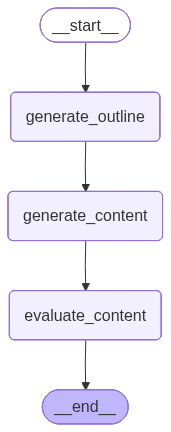

In [60]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [61]:
input_state = blogState(topic='The impact of AI on modern education', outline='', blog_post='', evaluation_score=0)
output_state = workflow.invoke(input_state)

In [62]:
output_state['evaluation_score'].content

9